In [1]:
import numpy as np

data = np.load('daymet_tmax_na_2010.npz')['arr_0']
for t in [11, 12, 13, 14, 15, 16, 17, 18, 19]:
    data = np.append(data, np.load('daymet_tmax_na_20{}.npz'.format(t))['arr_0'], axis = 1)

In [3]:
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.read_file("states.shp")
stations = np.load('stations.npz')['arr_0']
num = stations.shape[0]
pos = np.zeros((num, len(gdf['geometry'])))
for n in range(num):
    pt = Point(stations[n, 0], stations[n, 1])
    for r in range(len(gdf['geometry'])):
        if pt.within(gdf['geometry'][r]) == True:
            pos[n, r] = 1
        elif pt.within((gdf['geometry'][r])) == False:
            pos[n, r] = 0
pos = np.sum(pos, axis = 1)
station_us = stations[np.where(pos == 1)]

In [5]:
mat = data[np.where(pos == 1)[0], :]
mat.shape

(5380, 3650)

In [6]:
import numpy as np
from docplex.mp.model import Model

def ts_pair(x, d):
    T = x.shape[0]
    x_tilde = x[d : T]
    A = np.zeros((T - d, d))
    for k in range(d):
        A[:, k] = x[d - k - 1 : T - k - 1]
    return x_tilde, A

def data2para(mat, d):
    N = mat.shape[0]
    C = np.zeros((d, d))
    F = np.zeros(d)
    for n in range(N):
        x_tilde, A = ts_pair(mat[n, :], d)
        C += A.T @ A
        F += A.T @ x_tilde
    return C, F

def sparse_ar_mip(C, F, tau):
    model = Model(name = 'Sparse Autoregression')
    d = F.shape[0]
    w = [model.continuous_var(lb = 0, name = f'w_{k}') for k in range(d)]
    beta = [model.binary_var(name = f'beta_{k}') for k in range(d)]
    model.minimize(model.sum(w[k] * model.sum(w[t] * C[k, t] for t in range(d)) 
                             - 2 * w[k] * F[k] for k in range(d)))
    model.add_constraint(model.sum(beta[k] for k in range(d)) <= tau)
    model.add_constraint(model.sum(w[k] for k in range(d)) == 1)
    for k in range(d):
        model.add_constraint(w[k] <= beta[k])
    solution = model.solve()
    if solution:
        print(solution.get_values(w))
        w_coef = np.array(solution.get_values(w))
        ind = np.where(w_coef > 0)[0].tolist()
        print('Support set: ', ind)
        print('Coefficients w: ', w_coef[ind])
        print('Cardinality of support set: ', len(ind))
        return w_coef, ind
    else:
        print('No solution found.')
        return None

In [9]:
import numpy as np
from scipy.optimize import nnls

def sparse_ar_local(x, d, ind):
    T = x.shape[0]
    A = np.zeros((T - d, len(ind)))
    for k in range(len(ind)):
        A[:, k] = x[d - ind[k] - 1 : T - ind[k] - 1]
    w = np.zeros(d)
    w[ind], _ = nnls(A, x[d : T])
    return w

In [22]:
import time

N = mat.shape[0]
d = 365
C, F = data2para(mat, d)

tau = 5

start = time.time()
w, ind = sparse_ar_mip(C, F, tau)
W_tensor = np.zeros((N, d))
for n in range(N):
    W_tensor[n, :] = sparse_ar_local(mat[n, :], d, ind)
end = time.time()
print('Running time (s):', end - start)

[0.7009837775099287, 0, 0, 0, 0, 0.07666902503591266, 0, 0, 0, 0, 0, 0, 0, 0.07472404723098314, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [23]:
import time

N = mat.shape[0]
d = 365
C, F = data2para(mat, d)

tau = 10

start = time.time()
w, ind = sparse_ar_mip(C, F, tau)
W_tensor = np.zeros((N, d))
for n in range(N):
    W_tensor[n, :] = sparse_ar_local(mat[n, :], d, ind)
end = time.time()
print('Running time (s):', end - start)

[0.6722554894041123, 0, 0, 0, 0, 0.04386507691682269, 0, 0, 0, 0.03428119173317716, 0, 0, 0, 0.03374548346164681, 0, 0, 0, 0, 0.030162877103345778, 0, 0, 0, 0, 0, 0, 0, 0, 0.03535483423514257, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

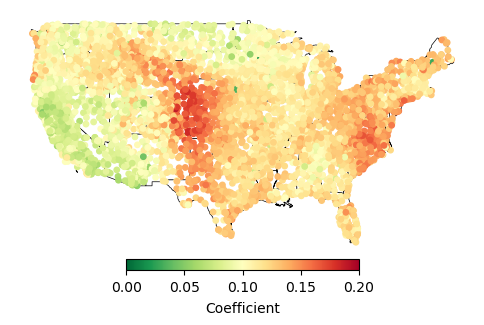

In [27]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize = (6, 4))
ax = fig.subplots(1)

gdf = gpd.read_file("states.shp")
gdf.plot(facecolor = 'white', edgecolor = 'black', linewidth = 0.5, ax = ax)

lon_lat = []
for i in range(station_us.shape[0]):
    lon_lat.append(Point(station_us[i, 0], station_us[i, 1]))
df = {'temp': np.sum(W_tensor[:, 334 :], axis = 1), 'geometry': lon_lat}

merged = gpd.GeoDataFrame(df, crs = "EPSG:4326")
merged.plot('temp', cmap = 'RdYlGn_r', markersize = 15, 
            legend = False, vmin = 0, vmax = 0.2,
            ax = ax)

mappable = ax.collections[-1]

# Create horizontal colorbar manually
cbar = fig.colorbar(
    mappable,
    ax=ax,
    orientation='horizontal',
    fraction=0.045,
    pad=0.01,
    shrink=0.50
)

cbar.set_label('Coefficient', labelpad=5)

plt.xticks([])
plt.yticks([])
for _, spine in ax.spines.items():
    spine.set_visible(False)
plt.show()
fig.savefig(f"usa_temp_season_pattern_tau_{tau}.pdf", bbox_inches = "tight")

In [28]:
import time

N = mat.shape[0]
d = 365
C, F = data2para(mat, d)

tau = 20

start = time.time()
w, ind = sparse_ar_mip(C, F, tau)
W_tensor = np.zeros((N, d))
for n in range(N):
    W_tensor[n, :] = sparse_ar_local(mat[n, :], d, ind)
end = time.time()
print('Running time (s):', end - start)

[0.6598241801100034, 0, 0, 0.025155503941957636, 0, 0.01920624743953737, 0.014680880691427768, 0, 0, 0.02501083708180633, 0, 0, 0, 0.020511595817914514, 0, 0.017439349590697612, 0, 0, 0.018871627532536354, 0, 0, 0, 0, 0, 0, 0.015716017848732035, 0, 0.02263305100161399, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

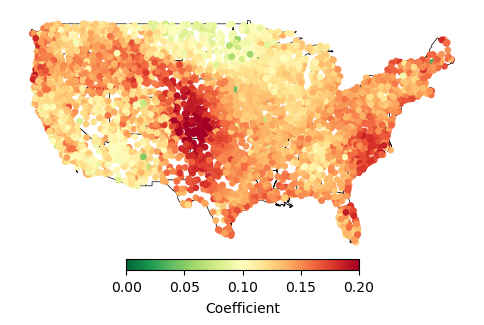

In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize = (6, 4))
ax = fig.subplots(1)

r = 5
gdf = gpd.read_file("states.shp")
gdf.plot(facecolor = 'white', edgecolor = 'black', linewidth = 0.5, ax = ax)

lon_lat = []
for i in range(station_us.shape[0]):
    lon_lat.append(Point(station_us[i, 0], station_us[i, 1]))
df = {'temp': np.sum(W_tensor[:, 334 :], axis = 1), 'geometry': lon_lat}

merged = gpd.GeoDataFrame(df, crs = "EPSG:4326")
merged.plot('temp', cmap = 'RdYlGn_r', markersize = 15, 
            legend = False, vmin = 0, vmax = 0.2,
            ax = ax)

mappable = ax.collections[-1]

# Create horizontal colorbar manually
cbar = fig.colorbar(
    mappable,
    ax=ax,
    orientation='horizontal',
    fraction=0.045,
    pad=0.01,
    shrink=0.50
)

cbar.set_label('Coefficient', labelpad=5)

plt.xticks([])
plt.yticks([])
for _, spine in ax.spines.items():
    spine.set_visible(False)
plt.show()
fig.savefig(f"usa_temp_season_pattern_tau_{tau}.pdf", bbox_inches = "tight")